In [ ]:
# ====== 1) Installs (PyTorch is already available in Colab usually) ======
# (Uncomment to reinstall/force specific versions if you want; usually not needed)
# !pip install -q torch torchvision torchaudio

# ====== 2) Imports & drive mount ======
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import time
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# ====== 3) PARAMETERS ======
# EDIT these paths to your drive file locations if needed
PATH_TRAIN = '/content/drive/My Drive/df_daily_final.csv'
PATH_EVAL  = '/content/drive/My Drive/df_daily_eval_final.csv'

ENCODER_LENGTH = 30   # history length used by N-BEATS
FORECAST_HORIZON = 7  # predict 7 days
BATCH_SIZE = 256
EPOCHS = 8            # change up for more training
LR = 1e-3
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

# reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

# ====== Columns to drop (as requested) ======
columns_to_drop = [
    'day_of_year_sin', 'day_of_year_cos', 'quarter_cos',
    'rolling_std_7_log', 'rolling_std_14_log','lag_1_discount',
    'prev_day_hourly_stock_active_ratio_active','week_of_year_sin',
    'week_of_year_cos','quarter_sin','days_since_last_promo',
    'stock_recovery','is_weekend','cv_14_log','roll_mean_28_log',
    'month_cos','month_sin'
]

# ====== 4) Load data ======
df_train = pd.read_csv(PATH_TRAIN)
df_eval = pd.read_csv(PATH_EVAL)
print("Loaded:", df_train.shape, df_eval.shape)

# ensure dt -> datetime
for df in (df_train, df_eval):
    if 'dt' in df.columns:
        df['dt'] = pd.to_datetime(df['dt'])
    elif 'ds' in df.columns:
        df['dt'] = pd.to_datetime(df['ds'])
    else:
        raise ValueError("No date column found; expected 'dt' or 'ds'")

# rename target to y_log (consistent)
if 'sale_amount_log' not in df_train.columns:
    raise ValueError("train file must contain 'sale_amount_log'")
df_train = df_train.rename(columns={'sale_amount_log':'y_log'})
df_eval = df_eval.rename(columns={'sale_amount_log':'y_log'})

# construct ID (store_product) if not present
df_train['ID'] = df_train['store_id'].astype(str) + "_" + df_train['product_id'].astype(str)
df_eval['ID']  = df_eval['store_id'].astype(str) + "_" + df_eval['product_id'].astype(str)

# Drop the unwanted columns if present (user requested)
for col in columns_to_drop:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])
    if col in df_eval.columns:
        df_eval = df_eval.drop(columns=[col])

# sort
df_train = df_train.sort_values(['ID','dt']).reset_index(drop=True)
df_eval  = df_eval.sort_values(['ID','dt']).reset_index(drop=True)

print("Unique series (train):", df_train['ID'].nunique())
print("Unique series (eval):", df_eval['ID'].nunique())

# ====== 4b) Identify dynamic covariates and static categoricals ======
# Exclude these control columns from dynamic features
exclude_cols = set(['ID','dt','y_log','sale_amount_log','store_id','product_id'])
# Also exclude any categorical static columns we'll treat separately
static_cats = ['store_id','product_id','management_group_id',
               'first_category_id','second_category_id','third_category_id']

# Build list of dynamic features = all remaining columns that are not excluded and not in static_cats
dyn_features = [c for c in df_train.columns if c not in exclude_cols and c not in static_cats]
dyn_features = sorted(dyn_features)  # deterministic order
print("Dynamic features (used in encoder):", dyn_features)
print("Static categorical features (embeddings):", static_cats)

# Fill missing values for dynamic features (simple)
df_train[dyn_features] = df_train[dyn_features].fillna(0.0)
df_eval[dyn_features]  = df_eval[dyn_features].fillna(0.0)

# ====== 4c) Scale dynamic features using StandardScaler fitted on train ======
scaler = StandardScaler()
# fit on all train dyn features (reshape flattened)
train_dyn_vals = df_train[dyn_features].values
scaler.fit(train_dyn_vals)
df_train[dyn_features] = scaler.transform(df_train[dyn_features].values)
df_eval[dyn_features]  = scaler.transform(df_eval[dyn_features].values)

# ====== 5) Build supervised sliding windows dataset (now with covariates) ======
def build_windows(df, encoder_length, forecast_horizon, dyn_features, for_train=True):
    samples = []
    for sid, group in df.groupby('ID'):
        grp = group.sort_values('dt').reset_index(drop=True)
        y = grp['y_log'].values.astype(float)
        n = len(y)
        end_last_index = n - forecast_horizon
        for start_enc in range(0, end_last_index - encoder_length + 1):
            enc_slice_y = y[start_enc : start_enc + encoder_length]
            dec_slice = y[start_enc + encoder_length : start_enc + encoder_length + forecast_horizon]
            # covariates for encoder (sequence of vectors length encoder_length)
            enc_cov = grp.loc[start_enc : start_enc + encoder_length - 1, dyn_features].values  # shape (encoder_length, n_dyn)
            # skip if any nan
            if np.isnan(enc_slice_y).any() or np.isnan(dec_slice).any() or np.isnan(enc_cov).any():
                continue
            samples.append({
                'ID': sid,
                'store_id': grp.loc[0,'store_id'],
                'product_id': grp.loc[0,'product_id'],
                'management_group_id': grp.loc[0].get('management_group_id', np.nan),
                'first_category_id': grp.loc[0].get('first_category_id', np.nan),
                'second_category_id': grp.loc[0].get('second_category_id', np.nan),
                'third_category_id': grp.loc[0].get('third_category_id', np.nan),
                'enc_y': enc_slice_y.copy(),                  # (encoder_length,)
                'enc_cov': enc_cov.copy(),                    # (encoder_length, n_dyn)
                'dec_y': dec_slice.copy(),                    # (forecast_horizon,)
                'last_date_index': grp.loc[start_enc + encoder_length - 1, 'dt']
            })
    return samples

print("Building training windows (this can take some time)...")
train_samples = build_windows(df_train, ENCODER_LENGTH, FORECAST_HORIZON, dyn_features, for_train=True)
print("Total train samples:", len(train_samples))

# Create mapping for static categories to small integers (for embeddings)
def make_map_for_col(df, col):
    values = sorted(df[col].dropna().unique())
    return {v:i for i,v in enumerate(values)}, len(values)

store_unique = sorted(df_train['store_id'].unique())
product_unique = sorted(df_train['product_id'].unique())
store_map = {v:i for i,v in enumerate(store_unique)}
product_map = {v:i for i,v in enumerate(product_unique)}
n_store = len(store_unique)
n_product = len(product_unique)

mg_map, n_mg = make_map_for_col(df_train, 'management_group_id')
cat1_map, n_cat1 = make_map_for_col(df_train, 'first_category_id')
cat2_map, n_cat2 = make_map_for_col(df_train, 'second_category_id')
cat3_map, n_cat3 = make_map_for_col(df_train, 'third_category_id')

print("n_store:", n_store, "n_product:", n_product, "n_mg:", n_mg, "n_cat1:", n_cat1, "n_cat2:", n_cat2, "n_cat3:", n_cat3)

# ====== Create train Dataset (returns flattened covariates) ======
class NBeatsDataset(Dataset):
    def __init__(self, samples, dyn_features, encoder_length):
        self.samples = samples
        self.dyn_features = dyn_features
        self.encoder_length = encoder_length
        self.n_dyn = len(dyn_features)
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        enc_y = s['enc_y'].astype(np.float32)        # shape (encoder_length,)
        enc_cov = s['enc_cov'].astype(np.float32)    # shape (encoder_length, n_dyn)
        # flatten covariates: (encoder_length * n_dyn,)
        enc_cov_flat = enc_cov.reshape(-1).astype(np.float32)
        dec_y = s['dec_y'].astype(np.float32)        # shape (forecast_horizon,)
        store_idx = store_map[int(s['store_id'])]
        prod_idx  = product_map[int(s['product_id'])]
        mg_idx = mg_map.get(s['management_group_id'], 0)
        cat1_idx = cat1_map.get(s['first_category_id'], 0)
        cat2_idx = cat2_map.get(s['second_category_id'], 0)
        cat3_idx = cat3_map.get(s['third_category_id'], 0)
        return {
            'enc_y': enc_y,
            'enc_cov_flat': enc_cov_flat,
            'dec_y': dec_y,
            'store_idx': store_idx,
            'prod_idx': prod_idx,
            'mg_idx': mg_idx,
            'cat1_idx': cat1_idx,
            'cat2_idx': cat2_idx,
            'cat3_idx': cat3_idx
        }

train_dataset = NBeatsDataset(train_samples, dyn_features, ENCODER_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, num_workers=2)

# ====== 6) Build N-BEATS model (simple implementation) ======
class NBeatsBlock(nn.Module):
    def __init__(self, input_dim, theta_dim, hidden_dim, n_layers):
        super().__init__()
        layers = []
        curr = input_dim
        for _ in range(n_layers):
            layers.append(nn.Linear(curr, hidden_dim))
            layers.append(nn.ReLU())
            curr = hidden_dim
        self.fc = nn.Sequential(*layers)
        self.theta_b = nn.Linear(curr, theta_dim)  # backcast coefficients
        self.theta_f = nn.Linear(curr, theta_dim)  # forecast coefficients

    def forward(self, x):
        x = self.fc(x)
        tb = self.theta_b(x)
        tf = self.theta_f(x)
        return tb, tf

class NBeatsModel(nn.Module):
    def __init__(self, encoder_length, forecast_horizon,
                 n_blocks=3, hidden_dim=256, n_layers=3,
                 embed_store=16, embed_prod=32,
                 n_store=None, n_product=None,
                 n_mg=None, n_cat1=None, n_cat2=None, n_cat3=None,
                 n_dyn=0, dropout=0.0):
        super().__init__()
        self.encoder_length = encoder_length
        self.forecast_horizon = forecast_horizon
        self.n_dyn = n_dyn

        # static embeddings
        self.embed_store = nn.Embedding(n_store, embed_store) if n_store is not None else None
        self.embed_prod  = nn.Embedding(n_product, embed_prod) if n_product is not None else None
        # additional static embeddings
        self.embed_mg   = nn.Embedding(n_mg, max(4, min(16, n_mg//2 + 1))) if n_mg is not None else None
        self.embed_cat1 = nn.Embedding(n_cat1, max(4, min(16, n_cat1//2 + 1))) if n_cat1 is not None else None
        self.embed_cat2 = nn.Embedding(n_cat2, max(4, min(16, n_cat2//2 + 1))) if n_cat2 is not None else None
        self.embed_cat3 = nn.Embedding(n_cat3, max(4, min(16, n_cat3//2 + 1))) if n_cat3 is not None else None

        # embedding totals
        emb_total = 0
        if self.embed_store is not None:
            emb_total += embed_store
        if self.embed_prod is not None:
            emb_total += embed_prod
        if self.embed_mg is not None:
            emb_total += self.embed_mg.embedding_dim
        if self.embed_cat1 is not None:
            emb_total += self.embed_cat1.embedding_dim
        if self.embed_cat2 is not None:
            emb_total += self.embed_cat2.embedding_dim
        if self.embed_cat3 is not None:
            emb_total += self.embed_cat3.embedding_dim

        # input dim = encoder_length (past y) + flattened covariates (encoder_length*n_dyn) + embeddings
        self.input_dim = encoder_length + (encoder_length * n_dyn) + emb_total

        # N-BEATS blocks
        self.blocks = nn.ModuleList()
        for _ in range(n_blocks):
            theta_dim = encoder_length + forecast_horizon
            block = NBeatsBlock(self.input_dim, theta_dim, hidden_dim, n_layers)
            self.blocks.append(block)

        self.dropout = nn.Dropout(dropout)

    def forward(self, enc_y, enc_cov_flat=None, store_idx=None, prod_idx=None,
                mg_idx=None, cat1_idx=None, cat2_idx=None, cat3_idx=None):
        # enc_y: batch x encoder_length
        batch = enc_y.shape[0]
        enc_y_flat = enc_y  # (batch, encoder_length)
        emb = []
        if self.embed_store is not None:
            emb.append(self.embed_store(store_idx))
        if self.embed_prod is not None:
            emb.append(self.embed_prod(prod_idx))
        if self.embed_mg is not None:
            emb.append(self.embed_mg(mg_idx))
        if self.embed_cat1 is not None:
            emb.append(self.embed_cat1(cat1_idx))
        if self.embed_cat2 is not None:
            emb.append(self.embed_cat2(cat2_idx))
        if self.embed_cat3 is not None:
            emb.append(self.embed_cat3(cat3_idx))
        if len(emb)>0:
            emb_cat = torch.cat(emb, dim=1)  # batch x emb_total
            if enc_cov_flat is not None:
                x = torch.cat([enc_y_flat, enc_cov_flat, emb_cat], dim=1)
            else:
                x = torch.cat([enc_y_flat, emb_cat], dim=1)
        else:
            if enc_cov_flat is not None:
                x = torch.cat([enc_y_flat, enc_cov_flat], dim=1)
            else:
                x = enc_y_flat

        forecast_sum = 0.0
        for block in self.blocks:
            tb, tf = block(x)
            tf_f = tf[:, self.encoder_length:]   # (batch, forecast_horizon)
            forecast_pred = tf_f
            forecast_sum = forecast_sum + forecast_pred

        return forecast_sum  # (batch, forecast_horizon)

# instantiate the model with n_dyn = len(dyn_features)
model = NBeatsModel(
    encoder_length=ENCODER_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    n_blocks=3,
    hidden_dim=256,
    n_layers=3,
    embed_store=16,
    embed_prod=32,
    n_store=n_store,
    n_product=n_product,
    n_mg=n_mg,
    n_cat1=n_cat1,
    n_cat2=n_cat2,
    n_cat3=n_cat3,
    n_dyn=len(dyn_features),
    dropout=0.1
).to(DEVICE)

print("Model params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# ====== 7) Training loop ======
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for batch in loader:
        enc_y = batch['enc_y'].to(device)                       # (B, enc_len)
        enc_cov_flat = batch['enc_cov_flat'].to(device)         # (B, enc_len * n_dyn)
        dec_y = batch['dec_y'].to(device)                       # (B, fh)
        store_idx = batch['store_idx'].to(device).long()
        prod_idx = batch['prod_idx'].to(device).long()
        mg_idx = batch['mg_idx'].to(device).long()
        cat1_idx = batch['cat1_idx'].to(device).long()
        cat2_idx = batch['cat2_idx'].to(device).long()
        cat3_idx = batch['cat3_idx'].to(device).long()

        optimizer.zero_grad()
        out = model(enc_y, enc_cov_flat=enc_cov_flat,
                    store_idx=store_idx, prod_idx=prod_idx,
                    mg_idx=mg_idx, cat1_idx=cat1_idx, cat2_idx=cat2_idx, cat3_idx=cat3_idx)  # (B, fh)
        loss = criterion(out, dec_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * enc_y.size(0)
    return running_loss / len(loader.dataset)

def validate_simple(model, df_train_local, df_eval_local, encoder_length, forecast_horizon, dyn_features, device):
    # produce predictions for every series using the last encoder_length values from df_train and compare to df_eval
    model.eval()
    preds = []
    trues = []
    ids = []
    ds_list = []
    with torch.no_grad():
        for sid, grp in df_train_local.groupby('ID'):
            grp = grp.sort_values('dt').reset_index(drop=True)
            if len(grp) < encoder_length + forecast_horizon:
                continue
            enc_y = grp['y_log'].values[-encoder_length:].astype(np.float32)[None,:]  # (1, enc_len)
            enc_cov = grp.loc[len(grp)-encoder_length:len(grp)-1, dyn_features].values.astype(np.float32)[None,:]  # (1, enc_len, n_dyn)
            enc_cov_flat = enc_cov.reshape(1, -1)
            store = store_map[int(grp.loc[0,'store_id'])]
            prod  = product_map[int(grp.loc[0,'product_id'])]
            mg = mg_map.get(grp.loc[0].get('management_group_id', np.nan), 0)
            cat1 = cat1_map.get(grp.loc[0].get('first_category_id', np.nan), 0)
            cat2 = cat2_map.get(grp.loc[0].get('second_category_id', np.nan), 0)
            cat3 = cat3_map.get(grp.loc[0].get('third_category_id', np.nan), 0)
            enc_t = torch.tensor(enc_y).to(device)
            enc_cov_t = torch.tensor(enc_cov_flat).to(device)
            out = model(enc_t, enc_cov_flat=enc_cov_t,
                        store_idx=torch.tensor([store],device=device),
                        prod_idx=torch.tensor([prod],device=device),
                        mg_idx=torch.tensor([mg],device=device),
                        cat1_idx=torch.tensor([cat1],device=device),
                        cat2_idx=torch.tensor([cat2],device=device),
                        cat3_idx=torch.tensor([cat3],device=device))
            out = out.squeeze(0).cpu().numpy()  # length fh
            eval_rows = df_eval_local[(df_eval_local['ID']==sid)].sort_values('dt')
            if len(eval_rows) < forecast_horizon:
                continue
            true_vals = eval_rows['y_log'].values[:forecast_horizon].astype(float)
            for i in range(forecast_horizon):
                preds.append(out[i])
                trues.append(true_vals[i])
                ids.append(sid)
                ds_list.append(eval_rows.iloc[i]['dt'])
    if len(preds)==0:
        return None
    preds = np.array(preds); trues = np.array(trues)
    preds_orig = np.expm1(preds)
    trues_orig = np.expm1(trues)
    rmse = math.sqrt(mean_squared_error(trues_orig, preds_orig))
    mae = mean_absolute_error(trues_orig, preds_orig)
    r2 = r2_score(trues_orig, preds_orig)
    wape = (np.sum(np.abs(trues_orig - preds_orig)) / (np.sum(trues_orig) + 1e-9)) * 100
    return {'rmse':rmse, 'mae':mae, 'r2':r2, 'wape':wape, 'count':len(preds)}

# training loop
best_val = None
start_time = time.time()
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = validate_simple(model, df_train, df_eval, ENCODER_LENGTH, FORECAST_HORIZON, dyn_features, DEVICE)
    t1 = time.time()
    print(f"Epoch {epoch}/{EPOCHS}  train_loss={train_loss:.6f}  time={t1-t0:.1f}s")
    if val_metrics is not None:
        print("  VAL -> RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, WAPE: {:.2f}%, count: {}".format(
            val_metrics['rmse'], val_metrics['mae'], val_metrics['r2'], val_metrics['wape'], val_metrics['count']
        ))
    else:
        print("  VAL -> no predictions (check eval alignment)")
end_time = time.time()
print("Training finished in {:.1f} minutes".format((end_time-start_time)/60))

# ====== 8) FINAL PREDICTIONS (per-series using last encoder window) ======
model.eval()
all_preds = []
all_trues = []
all_ids = []
all_ds = []
with torch.no_grad():
    for sid, grp in df_train.groupby('ID'):
        grp = grp.sort_values('dt').reset_index(drop=True)
        if len(grp) < ENCODER_LENGTH:
            continue
        enc_y = grp['y_log'].values[-ENCODER_LENGTH:].astype(np.float32)[None,:]
        enc_cov = grp.loc[len(grp)-ENCODER_LENGTH:len(grp)-1, dyn_features].values.astype(np.float32)[None,:]
        enc_cov_flat = enc_cov.reshape(1, -1)
        store = store_map[int(grp.loc[0,'store_id'])]
        prod  = product_map[int(grp.loc[0,'product_id'])]
        mg = mg_map.get(grp.loc[0].get('management_group_id', np.nan), 0)
        cat1 = cat1_map.get(grp.loc[0].get('first_category_id', np.nan), 0)
        cat2 = cat2_map.get(grp.loc[0].get('second_category_id', np.nan), 0)
        cat3 = cat3_map.get(grp.loc[0].get('third_category_id', np.nan), 0)
        enc_t = torch.tensor(enc_y).to(DEVICE)
        enc_cov_t = torch.tensor(enc_cov_flat).to(DEVICE)
        out = model(enc_t, enc_cov_flat=enc_cov_t,
                    store_idx=torch.tensor([store],device=DEVICE),
                    prod_idx=torch.tensor([prod],device=DEVICE),
                    mg_idx=torch.tensor([mg],device=DEVICE),
                    cat1_idx=torch.tensor([cat1],device=DEVICE),
                    cat2_idx=torch.tensor([cat2],device=DEVICE),
                    cat3_idx=torch.tensor([cat3],device=DEVICE))
        out = out.squeeze(0).cpu().numpy()
        eval_rows = df_eval[df_eval['ID']==sid].sort_values('dt')
        if len(eval_rows) < FORECAST_HORIZON:
            continue
        true_vals = eval_rows['y_log'].values[:FORECAST_HORIZON].astype(float)
        for i in range(FORECAST_HORIZON):
            all_preds.append(out[i])
            all_trues.append(true_vals[i])
            all_ids.append(sid)
            all_ds.append(eval_rows.iloc[i]['dt'])

# metrics on original scale
preds_orig = np.expm1(np.array(all_preds))
trues_orig = np.expm1(np.array(all_trues))

rmse = math.sqrt(mean_squared_error(trues_orig, preds_orig))
mae = mean_absolute_error(trues_orig, preds_orig)
r2 = r2_score(trues_orig, preds_orig)
wape = (np.sum(np.abs(trues_orig - preds_orig)) / (np.sum(trues_orig) + 1e-9)) * 100

print("\n===== FINAL METRICS (original scale) =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("WAPE :", f"{wape:.2f}%")
print("Pred rows:", len(preds_orig))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
Loaded: (460530, 50) (35819, 50)
Unique series (train): 5117
Unique series (eval): 5117
Dynamic features (used in encoder): ['activity_flag', 'avg_humidity', 'avg_temperature', 'avg_wind_level', 'binary_stockout', 'cv_7_log', 'day_of_week_cos', 'day_of_week_sin', 'days_since_last_stockout', 'discount', 'holiday_flag', 'is_month_end', 'is_month_start', 'lag_14_log', 'lag_1_log', 'lag_1_roll_14_interaction', 'lag_7_log', 'precpt', 'prev_day_hourly_sales_mean_active', 'prev_day_hourly_stockout_ratio_active', 'prev_sale_stock_interaction', 'roll_mean_14_log', 'roll_mean_7_log', 'sale_stock_ratio_previous_day', 'stock_hour6_22_cnt']
Static categorical features (embeddings): ['store_id', 'product_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id']
Building training windows (this can take some time)...
Total train 

In [ ]:
# ====== 9) FORECAST NEXT 7 DAYS BEYOND EVAL ======
model.eval()

future_forecasts = []

with torch.no_grad():
    for sid, grp in df_train.groupby('ID'):
        grp = grp.sort_values('dt').reset_index(drop=True)

        # Take last encoder window
        enc_y = grp['y_log'].values[-ENCODER_LENGTH:].astype(np.float32)[None,:]
        enc_cov = grp.loc[len(grp)-ENCODER_LENGTH:len(grp)-1, dyn_features].values.astype(np.float32)[None,:]
        enc_cov_flat = enc_cov.reshape(1, -1)

        store = store_map[int(grp.loc[0,'store_id'])]
        prod  = product_map[int(grp.loc[0,'product_id'])]
        mg = mg_map.get(grp.loc[0].get('management_group_id', np.nan), 0)
        cat1 = cat1_map.get(grp.loc[0].get('first_category_id', np.nan), 0)
        cat2 = cat2_map.get(grp.loc[0].get('second_category_id', np.nan), 0)
        cat3 = cat3_map.get(grp.loc[0].get('third_category_id', np.nan), 0)

        enc_t = torch.tensor(enc_y).to(DEVICE)
        enc_cov_t = torch.tensor(enc_cov_flat).to(DEVICE)

        out = model(
            enc_t,
            enc_cov_flat=enc_cov_t,
            store_idx=torch.tensor([store],device=DEVICE),
            prod_idx=torch.tensor([prod],device=DEVICE),
            mg_idx=torch.tensor([mg],device=DEVICE),
            cat1_idx=torch.tensor([cat1],device=DEVICE),
            cat2_idx=torch.tensor([cat2],device=DEVICE),
            cat3_idx=torch.tensor([cat3],device=DEVICE)
        )

        pred = np.expm1(out.cpu().numpy().reshape(-1))  # original scale

        # Build dates for the forecast horizon
        last_date = grp.loc[len(grp)-1, 'dt']
        forecast_dates = pd.date_range(last_date + pd.Timedelta(days=1),
                                       periods=FORECAST_HORIZON)

        for dt, val in zip(forecast_dates, pred):
            future_forecasts.append([sid, dt, val])

future_df = pd.DataFrame(future_forecasts, columns=['ID','dt','prediction'])
future_df.head()


,ID,dt,prediction
0,124_11,2024-06-26,0.427732
1,124_11,2024-06-27,0.452143
2,124_11,2024-06-28,0.359805
3,124_11,2024-06-29,0.369040
4,124_11,2024-06-30,0.478487


In [ ]:
# ====== 1) Installs (PyTorch is already available in Colab usually) ======
# (Uncomment to reinstall/force specific versions if you want; usually not needed)
# !pip install -q torch torchvision torchaudio

# ====== 2) Imports & drive mount ======
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import time
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# ====== 3) PARAMETERS ======
# EDIT these paths to your drive file locations if needed
PATH_TRAIN = '/content/drive/My Drive/df_daily_final.csv'
PATH_EVAL  = '/content/drive/My Drive/df_daily_eval_final.csv'

ENCODER_LENGTH = 30   # history length used by N-BEATS
FORECAST_HORIZON = 7  # predict 7 days
BATCH_SIZE = 256
EPOCHS = 8            # change up for more training
LR = 1e-3
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

# reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

# ====== Columns to drop (as requested) ======
columns_to_drop = [
    'day_of_year_sin', 'day_of_year_cos', 'quarter_cos',
    'rolling_std_7_log', 'rolling_std_14_log','lag_1_discount',
    'prev_day_hourly_stock_active_ratio_active','week_of_year_sin',
    'week_of_year_cos','quarter_sin','days_since_last_promo',
    'stock_recovery','is_weekend','cv_14_log','roll_mean_28_log',
    'month_cos','month_sin'
]

# ====== 4) Load data ======
df_train = pd.read_csv(PATH_TRAIN)
df_eval = pd.read_csv(PATH_EVAL)
print("Loaded:", df_train.shape, df_eval.shape)

# ensure dt -> datetime
for df in (df_train, df_eval):
    if 'dt' in df.columns:
        df['dt'] = pd.to_datetime(df['dt'])
    elif 'ds' in df.columns:
        df['dt'] = pd.to_datetime(df['ds'])
    else:
        raise ValueError("No date column found; expected 'dt' or 'ds'")

# rename target to y_log (consistent)
if 'sale_amount_log' not in df_train.columns:
    raise ValueError("train file must contain 'sale_amount_log'")
df_train = df_train.rename(columns={'sale_amount_log':'y_log'})
df_eval = df_eval.rename(columns={'sale_amount_log':'y_log'})

# construct ID (store_product) if not present
df_train['ID'] = df_train['store_id'].astype(str) + "_" + df_train['product_id'].astype(str)
df_eval['ID']  = df_eval['store_id'].astype(str) + "_" + df_eval['product_id'].astype(str)

# Drop the unwanted columns if present (user requested)
for col in columns_to_drop:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])
    if col in df_eval.columns:
        df_eval = df_eval.drop(columns=[col])

# sort
df_train = df_train.sort_values(['ID','dt']).reset_index(drop=True)
df_eval  = df_eval.sort_values(['ID','dt']).reset_index(drop=True)

print("Unique series (train):", df_train['ID'].nunique())
print("Unique series (eval):", df_eval['ID'].nunique())

# ====== 4b) Identify dynamic covariates and static categoricals ======
# Exclude these control columns from dynamic features
exclude_cols = set(['ID','dt','y_log','sale_amount_log','store_id','product_id'])
# Also exclude any categorical static columns we'll treat separately
static_cats = ['store_id','product_id','management_group_id',
               'first_category_id','second_category_id','third_category_id']

# Build list of dynamic features = all remaining columns that are not excluded and not in static_cats
dyn_features = [c for c in df_train.columns if c not in exclude_cols and c not in static_cats]
dyn_features = sorted(dyn_features)  # deterministic order
print("Dynamic features (used in encoder):", dyn_features)
print("Static categorical features (embeddings):", static_cats)

# Fill missing values for dynamic features (simple)
df_train[dyn_features] = df_train[dyn_features].fillna(0.0)
df_eval[dyn_features]  = df_eval[dyn_features].fillna(0.0)

# ====== 4c) Scale dynamic features using StandardScaler fitted on train ======
scaler = StandardScaler()
# fit on all train dyn features (reshape flattened)
train_dyn_vals = df_train[dyn_features].values
scaler.fit(train_dyn_vals)
df_train[dyn_features] = scaler.transform(df_train[dyn_features].values)
df_eval[dyn_features]  = scaler.transform(df_eval[dyn_features].values)

# ====== 5) Build supervised sliding windows dataset (now with covariates) ======
def build_windows(df, encoder_length, forecast_horizon, dyn_features, for_train=True):
    samples = []
    for sid, group in df.groupby('ID'):
        grp = group.sort_values('dt').reset_index(drop=True)
        y = grp['y_log'].values.astype(float)
        n = len(y)
        end_last_index = n - forecast_horizon
        for start_enc in range(0, end_last_index - encoder_length + 1):
            enc_slice_y = y[start_enc : start_enc + encoder_length]
            dec_slice = y[start_enc + encoder_length : start_enc + encoder_length + forecast_horizon]
            # covariates for encoder (sequence of vectors length encoder_length)
            enc_cov = grp.loc[start_enc : start_enc + encoder_length - 1, dyn_features].values  # shape (encoder_length, n_dyn)
            # skip if any nan
            if np.isnan(enc_slice_y).any() or np.isnan(dec_slice).any() or np.isnan(enc_cov).any():
                continue
            samples.append({
                'ID': sid,
                'store_id': grp.loc[0,'store_id'],
                'product_id': grp.loc[0,'product_id'],
                'management_group_id': grp.loc[0].get('management_group_id', np.nan),
                'first_category_id': grp.loc[0].get('first_category_id', np.nan),
                'second_category_id': grp.loc[0].get('second_category_id', np.nan),
                'third_category_id': grp.loc[0].get('third_category_id', np.nan),
                'enc_y': enc_slice_y.copy(),                  # (encoder_length,)
                'enc_cov': enc_cov.copy(),                    # (encoder_length, n_dyn)
                'dec_y': dec_slice.copy(),                    # (forecast_horizon,)
                'last_date_index': grp.loc[start_enc + encoder_length - 1, 'dt']
            })
    return samples

print("Building training windows (this can take some time)...")
train_samples = build_windows(df_train, ENCODER_LENGTH, FORECAST_HORIZON, dyn_features, for_train=True)
print("Total train samples:", len(train_samples))

# Create mapping for static categories to small integers (for embeddings)
def make_map_for_col(df, col):
    values = sorted(df[col].dropna().unique())
    return {v:i for i,v in enumerate(values)}, len(values)

store_unique = sorted(df_train['store_id'].unique())
product_unique = sorted(df_train['product_id'].unique())
store_map = {v:i for i,v in enumerate(store_unique)}
product_map = {v:i for i,v in enumerate(product_unique)}
n_store = len(store_unique)
n_product = len(product_unique)

mg_map, n_mg = make_map_for_col(df_train, 'management_group_id')
cat1_map, n_cat1 = make_map_for_col(df_train, 'first_category_id')
cat2_map, n_cat2 = make_map_for_col(df_train, 'second_category_id')
cat3_map, n_cat3 = make_map_for_col(df_train, 'third_category_id')

print("n_store:", n_store, "n_product:", n_product, "n_mg:", n_mg, "n_cat1:", n_cat1, "n_cat2:", n_cat2, "n_cat3:", n_cat3)

# ====== Create train Dataset (returns flattened covariates) ======
class NBeatsDataset(Dataset):
    def __init__(self, samples, dyn_features, encoder_length):
        self.samples = samples
        self.dyn_features = dyn_features
        self.encoder_length = encoder_length
        self.n_dyn = len(dyn_features)
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        enc_y = s['enc_y'].astype(np.float32)        # shape (encoder_length,)
        enc_cov = s['enc_cov'].astype(np.float32)    # shape (encoder_length, n_dyn)
        # flatten covariates: (encoder_length * n_dyn,)
        enc_cov_flat = enc_cov.reshape(-1).astype(np.float32)
        dec_y = s['dec_y'].astype(np.float32)        # shape (forecast_horizon,)
        store_idx = store_map[int(s['store_id'])]
        prod_idx  = product_map[int(s['product_id'])]
        mg_idx = mg_map.get(s['management_group_id'], 0)
        cat1_idx = cat1_map.get(s['first_category_id'], 0)
        cat2_idx = cat2_map.get(s['second_category_id'], 0)
        cat3_idx = cat3_map.get(s['third_category_id'], 0)
        return {
            'enc_y': enc_y,
            'enc_cov_flat': enc_cov_flat,
            'dec_y': dec_y,
            'store_idx': store_idx,
            'prod_idx': prod_idx,
            'mg_idx': mg_idx,
            'cat1_idx': cat1_idx,
            'cat2_idx': cat2_idx,
            'cat3_idx': cat3_idx
        }

train_dataset = NBeatsDataset(train_samples, dyn_features, ENCODER_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, num_workers=2)

# ====== 6) Build N-BEATS model (simple implementation) ======
class NBeatsBlock(nn.Module):
    def __init__(self, input_dim, theta_dim, hidden_dim, n_layers):
        super().__init__()
        layers = []
        curr = input_dim
        for _ in range(n_layers):
            layers.append(nn.Linear(curr, hidden_dim))
            layers.append(nn.ReLU())
            curr = hidden_dim
        self.fc = nn.Sequential(*layers)
        self.theta_b = nn.Linear(curr, theta_dim)  # backcast coefficients
        self.theta_f = nn.Linear(curr, theta_dim)  # forecast coefficients

    def forward(self, x):
        x = self.fc(x)
        tb = self.theta_b(x)
        tf = self.theta_f(x)
        return tb, tf

class NBeatsModel(nn.Module):
    def __init__(self, encoder_length, forecast_horizon,
                 n_blocks=3, hidden_dim=256, n_layers=3,
                 embed_store=16, embed_prod=32,
                 n_store=None, n_product=None,
                 n_mg=None, n_cat1=None, n_cat2=None, n_cat3=None,
                 n_dyn=0, dropout=0.0):
        super().__init__()
        self.encoder_length = encoder_length
        self.forecast_horizon = forecast_horizon
        self.n_dyn = n_dyn

        # static embeddings
        self.embed_store = nn.Embedding(n_store, embed_store) if n_store is not None else None
        self.embed_prod  = nn.Embedding(n_product, embed_prod) if n_product is not None else None
        # additional static embeddings
        self.embed_mg   = nn.Embedding(n_mg, max(4, min(16, n_mg//2 + 1))) if n_mg is not None else None
        self.embed_cat1 = nn.Embedding(n_cat1, max(4, min(16, n_cat1//2 + 1))) if n_cat1 is not None else None
        self.embed_cat2 = nn.Embedding(n_cat2, max(4, min(16, n_cat2//2 + 1))) if n_cat2 is not None else None
        self.embed_cat3 = nn.Embedding(n_cat3, max(4, min(16, n_cat3//2 + 1))) if n_cat3 is not None else None

        # embedding totals
        emb_total = 0
        if self.embed_store is not None:
            emb_total += embed_store
        if self.embed_prod is not None:
            emb_total += embed_prod
        if self.embed_mg is not None:
            emb_total += self.embed_mg.embedding_dim
        if self.embed_cat1 is not None:
            emb_total += self.embed_cat1.embedding_dim
        if self.embed_cat2 is not None:
            emb_total += self.embed_cat2.embedding_dim
        if self.embed_cat3 is not None:
            emb_total += self.embed_cat3.embedding_dim

        # input dim = encoder_length (past y) + flattened covariates (encoder_length*n_dyn) + embeddings
        self.input_dim = encoder_length + (encoder_length * n_dyn) + emb_total

        # N-BEATS blocks
        self.blocks = nn.ModuleList()
        for _ in range(n_blocks):
            theta_dim = encoder_length + forecast_horizon
            block = NBeatsBlock(self.input_dim, theta_dim, hidden_dim, n_layers)
            self.blocks.append(block)

        self.dropout = nn.Dropout(dropout)

    def forward(self, enc_y, enc_cov_flat=None, store_idx=None, prod_idx=None,
                mg_idx=None, cat1_idx=None, cat2_idx=None, cat3_idx=None):
        # enc_y: batch x encoder_length
        batch = enc_y.shape[0]
        enc_y_flat = enc_y  # (batch, encoder_length)
        emb = []
        if self.embed_store is not None:
            emb.append(self.embed_store(store_idx))
        if self.embed_prod is not None:
            emb.append(self.embed_prod(prod_idx))
        if self.embed_mg is not None:
            emb.append(self.embed_mg(mg_idx))
        if self.embed_cat1 is not None:
            emb.append(self.embed_cat1(cat1_idx))
        if self.embed_cat2 is not None:
            emb.append(self.embed_cat2(cat2_idx))
        if self.embed_cat3 is not None:
            emb.append(self.embed_cat3(cat3_idx))
        if len(emb)>0:
            emb_cat = torch.cat(emb, dim=1)  # batch x emb_total
            if enc_cov_flat is not None:
                x = torch.cat([enc_y_flat, enc_cov_flat, emb_cat], dim=1)
            else:
                x = torch.cat([enc_y_flat, emb_cat], dim=1)
        else:
            if enc_cov_flat is not None:
                x = torch.cat([enc_y_flat, enc_cov_flat], dim=1)
            else:
                x = enc_y_flat

        forecast_sum = 0.0
        for block in self.blocks:
            tb, tf = block(x)
            tf_f = tf[:, self.encoder_length:]   # (batch, forecast_horizon)
            forecast_pred = tf_f
            forecast_sum = forecast_sum + forecast_pred

        return forecast_sum  # (batch, forecast_horizon)

# instantiate the model with n_dyn = len(dyn_features)
model = NBeatsModel(
    encoder_length=ENCODER_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    n_blocks=3,
    hidden_dim=256,
    n_layers=3,
    embed_store=16,
    embed_prod=32,
    n_store=n_store,
    n_product=n_product,
    n_mg=n_mg,
    n_cat1=n_cat1,
    n_cat2=n_cat2,
    n_cat3=n_cat3,
    n_dyn=len(dyn_features),
    dropout=0.1
).to(DEVICE)

print("Model params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# ====== 7) Training loop ======
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for batch in loader:
        enc_y = batch['enc_y'].to(device)                       # (B, enc_len)
        enc_cov_flat = batch['enc_cov_flat'].to(device)         # (B, enc_len * n_dyn)
        dec_y = batch['dec_y'].to(device)                       # (B, fh)
        store_idx = batch['store_idx'].to(device).long()
        prod_idx = batch['prod_idx'].to(device).long()
        mg_idx = batch['mg_idx'].to(device).long()
        cat1_idx = batch['cat1_idx'].to(device).long()
        cat2_idx = batch['cat2_idx'].to(device).long()
        cat3_idx = batch['cat3_idx'].to(device).long()

        optimizer.zero_grad()
        out = model(enc_y, enc_cov_flat=enc_cov_flat,
                    store_idx=store_idx, prod_idx=prod_idx,
                    mg_idx=mg_idx, cat1_idx=cat1_idx, cat2_idx=cat2_idx, cat3_idx=cat3_idx)  # (B, fh)
        loss = criterion(out, dec_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * enc_y.size(0)
    return running_loss / len(loader.dataset)

def validate_simple(model, df_train_local, df_eval_local, encoder_length, forecast_horizon, dyn_features, device):
    # produce predictions for every series using the last encoder_length values from df_train and compare to df_eval
    model.eval()
    preds = []
    trues = []
    ids = []
    ds_list = []
    with torch.no_grad():
        for sid, grp in df_train_local.groupby('ID'):
            grp = grp.sort_values('dt').reset_index(drop=True)
            if len(grp) < encoder_length + forecast_horizon:
                continue
            enc_y = grp['y_log'].values[-encoder_length:].astype(np.float32)[None,:]  # (1, enc_len)
            enc_cov = grp.loc[len(grp)-encoder_length:len(grp)-1, dyn_features].values.astype(np.float32)[None,:]  # (1, enc_len, n_dyn)
            enc_cov_flat = enc_cov.reshape(1, -1)
            store = store_map[int(grp.loc[0,'store_id'])]
            prod  = product_map[int(grp.loc[0,'product_id'])]
            mg = mg_map.get(grp.loc[0].get('management_group_id', np.nan), 0)
            cat1 = cat1_map.get(grp.loc[0].get('first_category_id', np.nan), 0)
            cat2 = cat2_map.get(grp.loc[0].get('second_category_id', np.nan), 0)
            cat3 = cat3_map.get(grp.loc[0].get('third_category_id', np.nan), 0)
            enc_t = torch.tensor(enc_y).to(device)
            enc_cov_t = torch.tensor(enc_cov_flat).to(device)
            out = model(enc_t, enc_cov_flat=enc_cov_t,
                        store_idx=torch.tensor([store],device=device),
                        prod_idx=torch.tensor([prod],device=device),
                        mg_idx=torch.tensor([mg],device=device),
                        cat1_idx=torch.tensor([cat1],device=device),
                        cat2_idx=torch.tensor([cat2],device=device),
                        cat3_idx=torch.tensor([cat3],device=device))
            out = out.squeeze(0).cpu().numpy()  # length fh
            eval_rows = df_eval_local[(df_eval_local['ID']==sid)].sort_values('dt')
            if len(eval_rows) < forecast_horizon:
                continue
            true_vals = eval_rows['y_log'].values[:forecast_horizon].astype(float)
            for i in range(forecast_horizon):
                preds.append(out[i])
                trues.append(true_vals[i])
                ids.append(sid)
                ds_list.append(eval_rows.iloc[i]['dt'])
    if len(preds)==0:
        return None
    preds = np.array(preds); trues = np.array(trues)
    preds_orig = np.expm1(preds)
    trues_orig = np.expm1(trues)
    rmse = math.sqrt(mean_squared_error(trues_orig, preds_orig))
    mae = mean_absolute_error(trues_orig, preds_orig)
    r2 = r2_score(trues_orig, preds_orig)
    wape = (np.sum(np.abs(trues_orig - preds_orig)) / (np.sum(trues_orig) + 1e-9)) * 100
    return {'rmse':rmse, 'mae':mae, 'r2':r2, 'wape':wape, 'count':len(preds)}

# training loop
best_val = None
start_time = time.time()
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = validate_simple(model, df_train, df_eval, ENCODER_LENGTH, FORECAST_HORIZON, dyn_features, DEVICE)
    t1 = time.time()
    print(f"Epoch {epoch}/{EPOCHS}  train_loss={train_loss:.6f}  time={t1-t0:.1f}s")
    if val_metrics is not None:
        print("  VAL -> RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, WAPE: {:.2f}%, count: {}".format(
            val_metrics['rmse'], val_metrics['mae'], val_metrics['r2'], val_metrics['wape'], val_metrics['count']
        ))
    else:
        print("  VAL -> no predictions (check eval alignment)")
end_time = time.time()
print("Training finished in {:.1f} minutes".format((end_time-start_time)/60))

# ====== 8) FINAL PREDICTIONS (per-series using last encoder window) ======
model.eval()
all_preds = []
all_trues = []
all_ids = []
all_ds = []
with torch.no_grad():
    for sid, grp in df_train.groupby('ID'):
        grp = grp.sort_values('dt').reset_index(drop=True)
        if len(grp) < ENCODER_LENGTH:
            continue
        enc_y = grp['y_log'].values[-ENCODER_LENGTH:].astype(np.float32)[None,:]
        enc_cov = grp.loc[len(grp)-ENCODER_LENGTH:len(grp)-1, dyn_features].values.astype(np.float32)[None,:]
        enc_cov_flat = enc_cov.reshape(1, -1)
        store = store_map[int(grp.loc[0,'store_id'])]
        prod  = product_map[int(grp.loc[0,'product_id'])]
        mg = mg_map.get(grp.loc[0].get('management_group_id', np.nan), 0)
        cat1 = cat1_map.get(grp.loc[0].get('first_category_id', np.nan), 0)
        cat2 = cat2_map.get(grp.loc[0].get('second_category_id', np.nan), 0)
        cat3 = cat3_map.get(grp.loc[0].get('third_category_id', np.nan), 0)
        enc_t = torch.tensor(enc_y).to(DEVICE)
        enc_cov_t = torch.tensor(enc_cov_flat).to(DEVICE)
        out = model(enc_t, enc_cov_flat=enc_cov_t,
                    store_idx=torch.tensor([store],device=DEVICE),
                    prod_idx=torch.tensor([prod],device=DEVICE),
                    mg_idx=torch.tensor([mg],device=DEVICE),
                    cat1_idx=torch.tensor([cat1],device=DEVICE),
                    cat2_idx=torch.tensor([cat2],device=DEVICE),
                    cat3_idx=torch.tensor([cat3],device=DEVICE))
        out = out.squeeze(0).cpu().numpy()
        eval_rows = df_eval[df_eval['ID']==sid].sort_values('dt')
        if len(eval_rows) < FORECAST_HORIZON:
            continue
        true_vals = eval_rows['y_log'].values[:FORECAST_HORIZON].astype(float)
        for i in range(FORECAST_HORIZON):
            all_preds.append(out[i])
            all_trues.append(true_vals[i])
            all_ids.append(sid)
            all_ds.append(eval_rows.iloc[i]['dt'])

# metrics on original scale
preds_orig = np.expm1(np.array(all_preds))
trues_orig = np.expm1(np.array(all_trues))

rmse = math.sqrt(mean_squared_error(trues_orig, preds_orig))
mae = mean_absolute_error(trues_orig, preds_orig)
r2 = r2_score(trues_orig, preds_orig)
wape = (np.sum(np.abs(trues_orig - preds_orig)) / (np.sum(trues_orig) + 1e-9)) * 100

print("\n===== FINAL METRICS (original scale) =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("WAPE :", f"{wape:.2f}%")
print("Pred rows:", len(preds_orig))


Mounted at /content/drive
Device: cpu
Loaded: (460530, 50) (35819, 50)
Unique series (train): 5117
Unique series (eval): 5117
Dynamic features (used in encoder): ['activity_flag', 'avg_humidity', 'avg_temperature', 'avg_wind_level', 'binary_stockout', 'cv_7_log', 'day_of_week_cos', 'day_of_week_sin', 'days_since_last_stockout', 'discount', 'holiday_flag', 'is_month_end', 'is_month_start', 'lag_14_log', 'lag_1_log', 'lag_1_roll_14_interaction', 'lag_7_log', 'precpt', 'prev_day_hourly_sales_mean_active', 'prev_day_hourly_stockout_ratio_active', 'prev_sale_stock_interaction', 'roll_mean_14_log', 'roll_mean_7_log', 'sale_stock_ratio_previous_day', 'stock_hour6_22_cnt']
Static categorical features (embeddings): ['store_id', 'product_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id']
Building training windows (this can take some time)...
Total train samples: 276318
n_store: 107 n_product: 299 n_mg: 7 n_cat1: 27 n_cat2: 61 n_cat3: 153
Model params: 114

# Task
Calculate residuals from `preds_orig` and `trues_orig`. Then, generate diagnostic plots including a histogram of the residuals and a scatter plot of residuals against predicted values. Additionally, create an actual vs. predicted scatter plot with a diagonal reference line. Summarize the insights gained from these plots regarding model performance and error patterns.

## Calculate Residuals

### Subtask:
Calculate the residuals by subtracting the predicted values (`preds_orig`) from the actual values (`trues_orig`).


**Reasoning**:
Calculate the residuals by subtracting the predicted values from the actual values, as instructed.



In [ ]:
residuals = trues_orig - preds_orig
print("First 5 residuals:", residuals[:5])

First 5 residuals: [-0.02773205  0.54785705  0.44019492  0.23096008  0.12151293]


**Reasoning**:
Generate a histogram of the residuals to visualize their distribution, which helps in understanding model bias and error patterns.



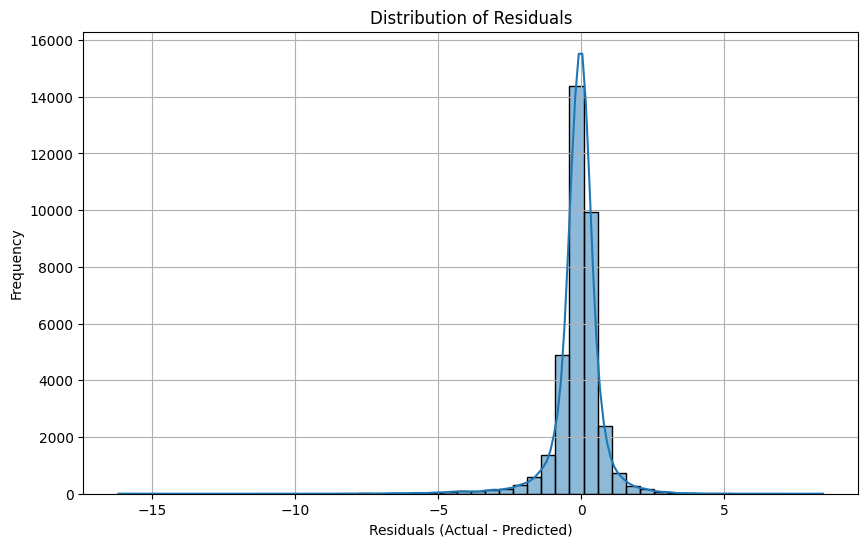

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**Reasoning**:
Generate a scatter plot of residuals against predicted values to check for heteroscedasticity or other patterns in the errors.



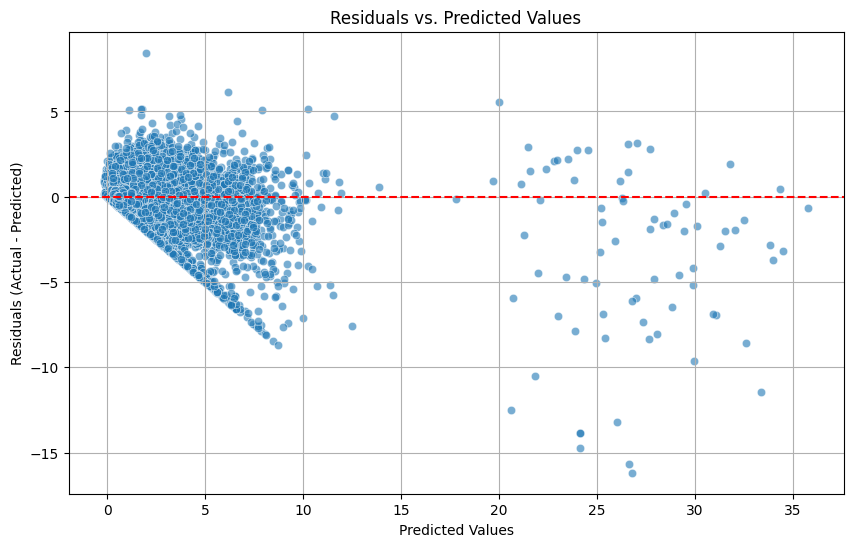

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=preds_orig, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

**Reasoning**:
Generate an actual vs. predicted values scatter plot with a diagonal reference line to visually assess the model's overall performance and agreement between predictions and actuals.



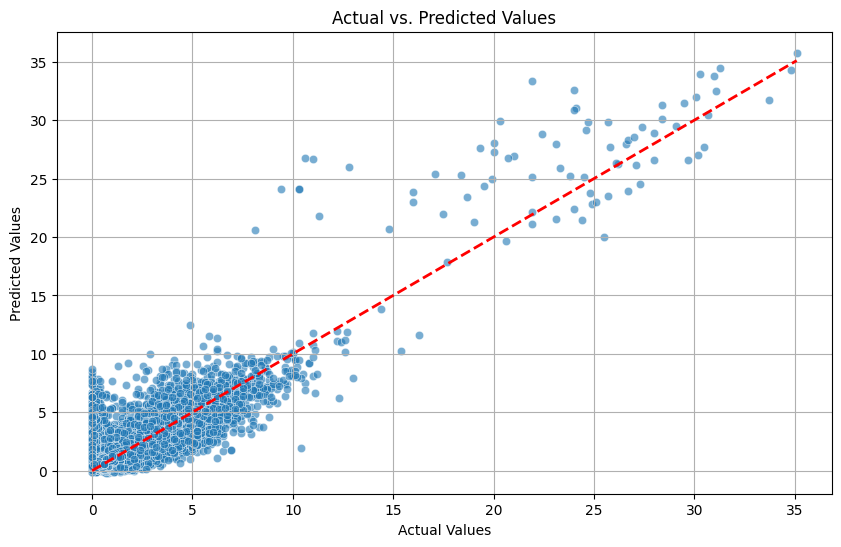

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=trues_orig, y=preds_orig, alpha=0.6)
plt.plot([min(trues_orig), max(trues_orig)], [min(trues_orig), max(trues_orig)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

In [ ]:
print(f"Range of Actual Original Sales: [{np.min(trues_orig):.2f}, {np.max(trues_orig):.2f}]")
print(f"Range of Predicted Original Sales: [{np.min(preds_orig):.2f}, {np.max(preds_orig):.2f}]")

Range of Actual Original Sales: [0.00, 35.10]
Range of Predicted Original Sales: [-0.18, 35.77]


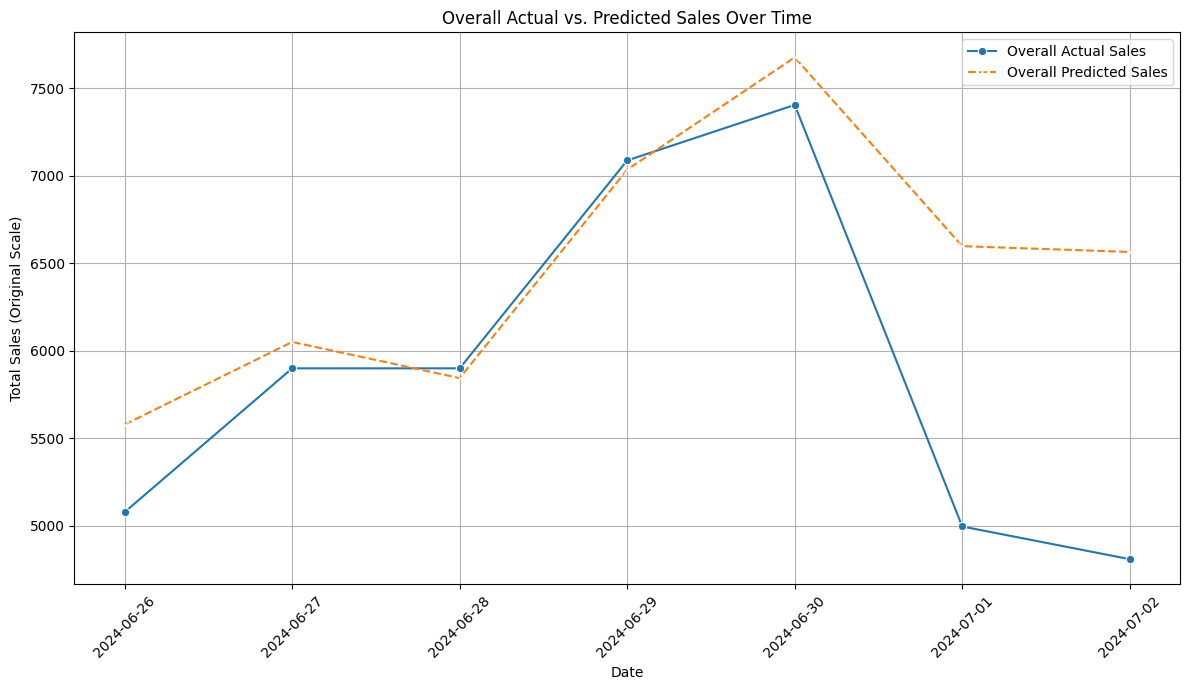

In [ ]:
df_results_agg = df_results.groupby('dt')[['Actual', 'Predicted']].sum().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_results_agg, x='dt', y='Actual', label='Overall Actual Sales', marker='o')
sns.lineplot(data=df_results_agg, x='dt', y='Predicted', label='Overall Predicted Sales', linestyle='--', marker='x')

plt.title('Overall Actual vs. Predicted Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales (Original Scale)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, ttest_1samp
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
import statsmodels.api as sm


### 1. Test for Normality of Residuals (Shapiro-Wilk Test)

The Shapiro-Wilk test tests the null hypothesis that the data was drawn from a normal distribution. A low p-value (typically < 0.05) indicates that the residuals are *not* normally distributed.

In [ ]:
stat, p = shapiro(residuals)
print('Shapiro-Wilk Test for Normality:')
print(f'  Statistic=%.3f, p=%.3f' % (stat, p))

if p > 0.05:
    print('  Result: Residuals appear to be normally distributed (fail to reject H0)')
else:
    print('  Result: Residuals do not appear to be normally distributed (reject H0)')


Shapiro-Wilk Test for Normality:
  Statistic=0.770, p=0.000
  Result: Residuals do not appear to be normally distributed (reject H0)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 35819.
  res = hypotest_fun_out(*samples, **kwds)


### 2. Test for Autocorrelation of Residuals (Ljung-Box Test)

The Ljung-Box test checks for autocorrelation in the residuals over several lags. The null hypothesis is that the residuals are independently distributed (i.e., no autocorrelation). A low p-value suggests the presence of autocorrelation, meaning the model might not have captured all temporal dependencies.

In [ ]:
lb_test = acorr_ljungbox(residuals, lags=[1, 5, 10, 20], return_df=True)
print('Ljung-Box Test for Autocorrelation:')
print(lb_test)

# Interpretation for a specific lag, e.g., lag 1
if lb_test.loc[1, 'lb_pvalue'] < 0.05:
    print('\n  Result (lag 1): Autocorrelation present (reject H0)')
else:
    print('\n  Result (lag 1): No significant autocorrelation (fail to reject H0)')


Ljung-Box Test for Autocorrelation:
        lb_stat  lb_pvalue
1   4424.312109        0.0
5   5591.807591        0.0
10  5638.409415        0.0
20  5747.366572        0.0

  Result (lag 1): Autocorrelation present (reject H0)


### 3. Test for Homoscedasticity of Residuals (Breusch-Pagan Test)

The Breusch-Pagan test checks for heteroscedasticity, meaning if the variance of the residuals is constant across all levels of the predicted values. The null hypothesis is homoscedasticity. A low p-value indicates heteroscedasticity (non-constant variance).

In [ ]:
# To perform the Breusch-Pagan test, we need the original features (X) used for prediction.
# Since N-BEATS is complex, we'll use predicted values as a proxy for the 'exog' (explanatory variables).
# This is a simplification; a full test would involve the model's internal features if accessible.

# Add a constant term to the predicted values, as required by statsmodels for some tests
X_pred = sm.add_constant(preds_orig)

# Ensure residuals are 1-D for the test
residuals_1d = residuals.flatten() if residuals.ndim > 1 else residuals

bp_test = het_breuschpagan(residuals_1d, X_pred)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print('Breusch-Pagan Test for Homoscedasticity:')
for i, (label, val) in enumerate(zip(labels, bp_test)):
    print(f'  {label}: {val:.3f}')

if bp_test[1] < 0.05: # Using LM-Test p-value for interpretation
    print('  Result: Heteroscedasticity present (reject H0)')
else:
    print('  Result: Homoscedasticity present (fail to reject H0)')


Breusch-Pagan Test for Homoscedasticity:
  LM Statistic: 8498.314
  LM-Test p-value: 0.000
  F-Statistic: 11141.159
  F-Test p-value: 0.000
  Result: Heteroscedasticity present (reject H0)


### 4. Test for Mean of Residuals (One-Sample t-test)

This test checks if the mean of the residuals is significantly different from zero. If the mean is significantly non-zero, it suggests a bias in the model (systematic over or under-prediction). The null hypothesis is that the mean of the residuals is zero.

In [ ]:
stat, p = ttest_1samp(residuals, 0)
print('One-Sample t-test for Mean of Residuals = 0:')
print(f'  Statistic=%.3f, p=%.3f' % (stat, p))

if p > 0.05:
    print('  Result: Mean of residuals is not significantly different from zero (fail to reject H0)')
else:
    print('  Result: Mean of residuals is significantly different from zero (reject H0)')


One-Sample t-test for Mean of Residuals = 0:
  Statistic=-25.797, p=0.000
  Result: Mean of residuals is significantly different from zero (reject H0)


In [ ]:
df_train.columns

Index(['store_id', 'management_group_id', 'first_category_id',
       'second_category_id', 'third_category_id', 'product_id', 'dt',
       'stock_hour6_22_cnt', 'discount', 'holiday_flag', 'activity_flag',
       'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level', 'y_log',
       'lag_1_log', 'lag_7_log', 'lag_14_log', 'roll_mean_7_log',
       'roll_mean_14_log', 'is_month_start', 'is_month_end', 'day_of_week_sin',
       'day_of_week_cos', 'cv_7_log', 'binary_stockout',
       'sale_stock_ratio_previous_day', 'prev_sale_stock_interaction',
       'lag_1_roll_14_interaction', 'prev_day_hourly_sales_mean_active',
       'prev_day_hourly_stockout_ratio_active', 'days_since_last_stockout',
       'ID'],
      dtype='object')